In [1]:
%matplotlib widget
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
from numba import njit
import matplotlib.animation as animation
from matplotlib.widgets import Slider
import pandas as pd
from fss import DataCollapse
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor
import matplotlib as mpl

In [2]:
@njit
def apply_noise(psi, p):
    flip = np.random.rand(*psi.shape) < p
    return np.where(flip, -psi, psi)

@njit
def s_ij(psi_m, psi_p):
        return psi_m*psi_p

### Zero Temperature Glauber

In [3]:

@njit
def Glauber_sweep(psi,J): 
        #whole lattice update (but individual sites still selected probabilistically)
        L = psi.shape[0]
        DE = 0
        for _ in range(L*L): #random sequential update rule as opposed to a systematic sweep ensuring every site is covered. 
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            
            DE = 0
            
            #calculate syndromes with nns vertically
            DE += s_ij(psi[i,j], psi[(i+1) % L, j])
            DE += s_ij(psi[i,j], psi[(i-1) % L, j])
            DE += s_ij(psi[i,j], psi[i, (j+1) % L])
            DE += s_ij(psi[i,j], psi[i, (j-1) % L])
            
            DE *= 2*J

            if DE < 0:
                psi[i,j] *= -1
            elif DE ==  0:
                if np.random.rand() < 0.5:
                        psi[i,j] *= -1
        return psi


@njit
def Glauber_sweeps(psi, sweeps):
        for _ in range(sweeps):
                psi = Glauber_sweep(psi)
        return psi

### Testing for threshold

In [4]:
@njit
def FullEvolution(L, pnoise, T, J): #kind of similar to a previous function but useful because I initialize new state every time, also only T added not noise
    max_sweeps = 5*L*L #more generous 
    early_stop = 2*L*L

    psi_i = np.ones((L, L), dtype=np.int64)
    psi_i = apply_noise(psi_i,pnoise)
    psi_G = psi_i.copy()

    last_m = np.sum(psi_G)
    unchanged = 0 
    
    for t in range(max_sweeps): #doing in different loops so I can individually break them 
        psi_G = Glauber_sweep(psi_G, J)
        m = np.sum(psi_G)
        
        if np.abs(np.sum(psi_G)) == L*L:
            break
        if m == last_m:
            unchanged += 1
            if unchanged > early_stop:
                break
        else: 
            last_m = m
            unchanged = 0
    return psi_G

In [5]:
@njit
def FullEvolution_no_early_stop(L,pnoise, T, J): #kind of similar to a previous function but useful because I initialize new state every time, also only T added not noise
    max_sweeps = L*L*L

    psi_i = np.ones((L, L), dtype=np.int64)
    psi_i = apply_noise(psi_i,pnoise)
    psi_G = psi_i.copy()

    last_m = np.sum(psi_G)
    unchanged = 0 
    
    for t in range(max_sweeps): #doing in different loops so I can individually break them 
        psi_G = Glauber_sweep(psi_G, J)
        if np.abs(np.sum(psi_G)) == L*L:
            break
    return psi_G

## Noise Dependence

In [6]:
def Noise_analysis(L_arr, p_arr):
    J = 1
    Tn = 0.0
    trials = 800 
    flogical_arr = {L: [] for L in L_arr}
    fconv_arr = {L: [] for L in L_arr}
    SE_arr = {L: [] for L in L_arr}

    for L_i in L_arr:
        for p_i in p_arr:
            logical_fail = 0 
            convergence_fail = 0
            for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
                state_f = FullEvolution(L_i, p_i, Tn, J)
                if np.sum(state_f)/(L_i*L_i) != 1:
                    logical_fail  += 1
                if abs(np.sum(state_f))/(L_i*L_i) != 1:
                    convergence_fail +=1
            lfp = logical_fail/trials 
            cfp = convergence_fail/trials
            SE = np.sqrt(lfp*(1-lfp)/trials)
            flogical_arr[L_i].append(lfp)
            SE_arr[L_i].append(SE)
            fconv_arr[L_i].append(cfp)
    return flogical_arr, SE_arr, fconv_arr

In [7]:
_,SE,_ = Noise_analysis([10],[0.49,0.5,0.51])
print("standard error:", SE)

L=10, p=0.51: 100%|██████████| 800/800 [00:00<00:00, 1736.45it/s]

standard error: {10: [np.float64(0.0174048753945554), np.float64(0.016575996859163555), np.float64(0.016240141240149362)]}


In [ ]:
# Run with current threshold
L_test = 60
p_test = np.linspace(0.45,0.55,10)
trials = 100  # fewer trials just for the test

pf_normal = []
pf_no_stop = []

for p in p_test:
    fail_normal = 0
    fail_no_stop = 0
    for _ in tqdm(range(trials),desc =f"p={p}"):
        # current stopping criteria
        state1 = FullEvolution(L_test, p, 0.0, 1)
        if np.sum(state1) / (L_test * L_test) != 1.0:
            fail_normal += 1
        
        # no early stopping — just max sweeps
        state2 = FullEvolution_no_early_stop(L_test, p, 0.0, 1)
        if np.sum(state2) / (L_test * L_test) != 1.0:
            fail_no_stop += 1
    
    pf_normal.append(fail_normal / trials)
    pf_no_stop.append(fail_no_stop / trials)

p=0.45:  21%|██        | 21/100 [00:24<02:52,  2.18s/it]

NameError: name 'p_test' is not defined

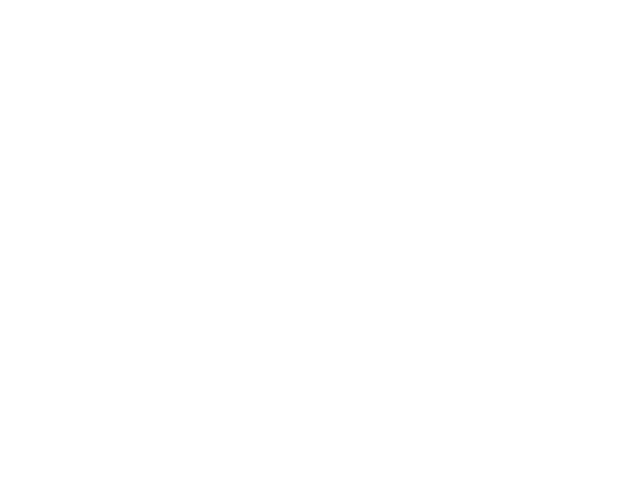

In [7]:
# plot comparison
plt.figure()
plt.plot(p_test, pf_normal,   'o-', markersize = 5, label='with early stopping')
plt.plot(p_test, pf_no_stop,  's--', markersize = 5, label='no early stopping')
plt.xlabel('p')
plt.ylabel('$p_{\ell f}(p)$')
plt.xlim(0.40,0.60)
plt.legend()
plt.legend(title='$L = 30$', title_fontsize=12)
plt.tight_layout()
plt.savefig('2DIsingStopTestL40.pdf', bbox_inches='tight') 
plt.show()

In [90]:
#Search Parameters and Arrays
L_arr = [20,30,40]
p_arr = np.linspace(0.3,0.7, 30)

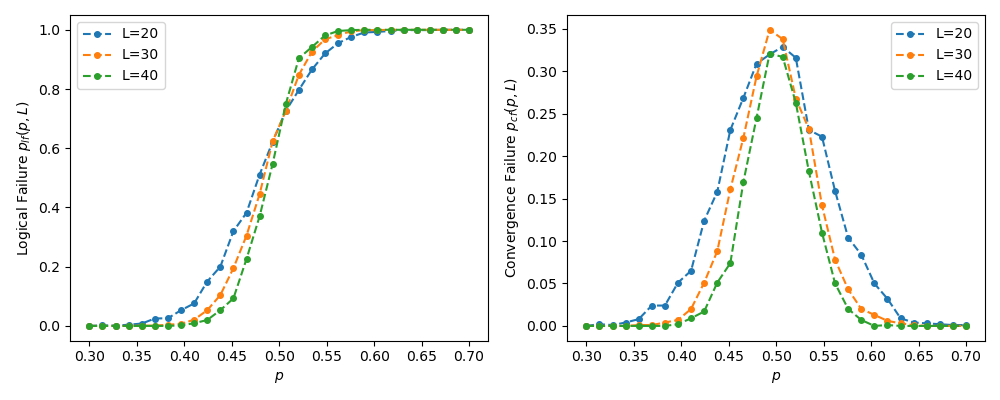

In [92]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
for L in L_arr:
    ax1.plot(p_arr, flogical_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    ax2.plot(p_arr, fconv_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    
#ax1.set_title("Logical Failure")
ax1.set_xlabel("$p$")
ax1.set_ylabel("Logical Failure $p_{lf}(p,L)$")

#ax2.set_title("GS Convergece Failure")
ax2.set_xlabel("$p$")
ax2.set_ylabel("Convergence Failure $p_{cf}(p,L)$")

ax1.legend()
ax2.legend()

plt.savefig('2DIsingIm5.png') 

plt.tight_layout() 

plt.show()

In [ ]:
#Search Parameters and Arrays
L_arrdc = [20,40,60,80]
p_arrdc = np.linspace(0.48,0.52, 20)
flogical_arrdc, SE_arrdc, fconv_arrdc = Noise_analysis(L_arrdc, p_arrdc)

L=20, p=0.49:  73%|███████▎  | 584/800 [00:04<00:01, 142.70it/s]

def run_single_trial_2D(args):
    L, p, J, Tn, seed = args
    np.random.seed(seed)
    state_f = FullEvolution(L, p, Tn, J)
    m = np.sum(state_f) / (L * L)
    logical_fail     = 1 if m != 1.0 else 0
    convergence_fail = 1 if abs(m) != 1.0 else 0
    return logical_fail, convergence_fail

### Parallel analysis - not worth it I found
def Noise_analysis_parallel(L_arr, p_arr, trials=800, n_workers=5):

    J  = 1
    Tn = 0.0
    
    flogical_arr = {L: [] for L in L_arr}
    fconv_arr    = {L: [] for L in L_arr}
    SE_arr       = {L: [] for L in L_arr}

    for L_i in L_arr:
        for p_i in p_arr:
            seeds = np.random.randint(0, 1_000_000, size=trials)
            args  = [(L_i, p_i, J, Tn, s) for s in seeds]

            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                results = list(tqdm(
                    ex.map(run_single_trial_2D, args),
                    total=trials,
                    desc=f"L={L_i}, p={p_i:.4f}"
                ))

            lf, cf  = zip(*results)
            lfp     = sum(lf) / trials
            cfp     = sum(cf) / trials
            SE      = np.sqrt(lfp * (1 - lfp) / trials)

            flogical_arr[L_i].append(lfp)
            SE_arr[L_i].append(SE)
            fconv_arr[L_i].append(cfp)

    return flogical_arr, SE_arr, fconv_arr

if __name__ == '__main__':
    L_arrdc = [20, 40, 60, 80]
    p_arrdc = np.linspace(0.48, 0.52, 20)
    flogical_arrdc, SE_arrdc, fconv_arrdc = Noise_analysis_parallel(L_arrdc, p_arrdc, trials=800, n_workers=4)

In [183]:
#Storing as dataset just in case
rows_data = []
for L in L_arrdc:
    for i in range(len(p_arrdc)):
        dict = {'p': p_arrdc[i], 'L': L, 'pf': flogical_arrdc[L][i], 'SE':SE_arrdc[L][i], 'conv': fconv_arrdc[L][i]}
        rows_data.append(dict)
df = pd.DataFrame(rows_data)
print(df)

df.to_csv('2DIsingDataCollapse.csv', index= False)

           p   L    pf        SE  conv
0   0.480000  20  0.49  0.049990  0.30
1   0.482857  20  0.61  0.048775  0.49
2   0.485714  20  0.57  0.049508  0.38
3   0.488571  20  0.58  0.049356  0.33
4   0.491429  20  0.64  0.048000  0.36
5   0.494286  20  0.62  0.048539  0.30
6   0.497143  20  0.59  0.049183  0.35
7   0.500000  20  0.57  0.049508  0.26
8   0.502857  20  0.69  0.046249  0.29
9   0.505714  20  0.72  0.044900  0.38
10  0.508571  20  0.68  0.046648  0.36
11  0.511429  20  0.79  0.040731  0.37
12  0.514286  20  0.74  0.043863  0.29
13  0.517143  20  0.73  0.044396  0.29
14  0.520000  20  0.79  0.040731  0.26
15  0.480000  40  0.49  0.049990  0.32
16  0.482857  40  0.40  0.048990  0.21
17  0.485714  40  0.45  0.049749  0.27
18  0.488571  40  0.49  0.049990  0.31
19  0.491429  40  0.61  0.048775  0.39
20  0.494286  40  0.63  0.048280  0.36
21  0.497143  40  0.74  0.043863  0.23
22  0.500000  40  0.72  0.044900  0.39
23  0.502857  40  0.63  0.048280  0.26
24  0.505714  40  0.82  0

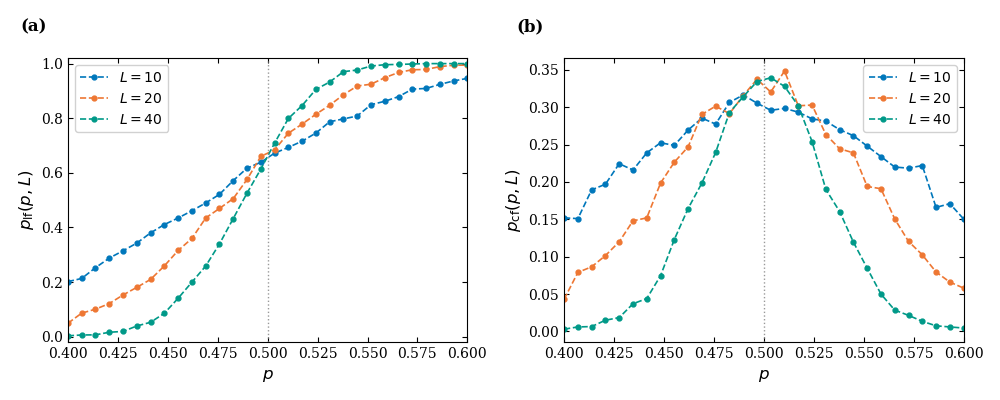

In [184]:
figure_data = pd.read_csv('2DIsingLFPCFPfigure.csv')


colors = ['#0077BB', '#EE7733', '#009988', '#CC3311']

mpl.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.linewidth':    0.8,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'legend.fontsize':   10,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '0.8',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

for idx, L in enumerate(L_arr2):
    ax1.plot(p_arr2, flogical_arr2[L],
             linestyle='--', marker='o', markersize=3.5,
             linewidth=1.2, color=colors[idx], label=f'$L={L}$')
    ax2.plot(p_arr2, fconv_arr2[L],
             linestyle='--', marker='o', markersize=3.5,
             linewidth=1.2, color=colors[idx], label=f'$L={L}$')

'''
for L in L_arr2:
    ax1.plot(p_arr2, flogical_arr2[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    ax2.plot(p_arr2, fconv_arr2[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
'''

for ax in (ax1, ax2):
    ax.axvline(0.5, color='gray', linewidth=1, 
               linestyle=':', alpha=0.8)
    
#ax1.set_title("Logical Failure")
ax1.set_xlabel("$p$")
ax1.set_xlim(0.4,0.6)
ax1.set_ylabel('$p_{\\mathrm{lf}}(p,L)$')
ax1.set_ylim(-0.02, 1.02)
#ax1.legend(title='System size', title_fontsize=9)
#ax2.set_title("GS Convergece Failure")
ax2.set_xlabel("$p$")
ax2.set_xlim(0.4,0.6)
ax2.set_ylabel('$p_{\\mathrm{cf}}(p,L)$')
#ax2.set_ylim(-0.02, 0.35)

ax1.legend()
ax2.legend()

# outside top-left, above the axes
ax1.text(-0.12, 1.08, '(a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='bottom', ha='left')
ax2.text(-0.12, 1.08, '(b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='bottom', ha='left')

plt.savefig('2DIsingIm8.png') 

plt.tight_layout() 

plt.show()

In [185]:
df = pd.read_csv('2DIsingDataCollapse.csv')
df_collapse = df[['p', 'L', 'pf', 'SE']].copy()

# clip SE to avoid division by zero — floor at 1/trials
trials = 1000
df_collapse['SE'] = df_collapse['SE'].clip(lower=1/trials)

# adapt to package format
df_collapse = df_collapse.rename(columns={'pf': 'estimator', 'SE': 'standard_error'})
df_collapse = df_collapse[df_collapse['L'] != 2]
df_collapse = df_collapse.set_index(['p', 'L'])
df_collapse

,,estimator,standard_error
p,L,,
0.480000,20,0.49,0.049990
0.482857,20,0.61,0.048775
0.485714,20,0.57,0.049508
0.488571,20,0.58,0.049356
0.491429,20,0.64,0.048000
0.494286,20,0.62,0.048539
0.497143,20,0.59,0.049183
0.500000,20,0.57,0.049508
0.502857,20,0.69,0.046249


p_c=0.4967, nu=1.0385, chi2=0.8266
p_c error=(0.4951, 0.4997), nu error=(0.7044, 1.5000)


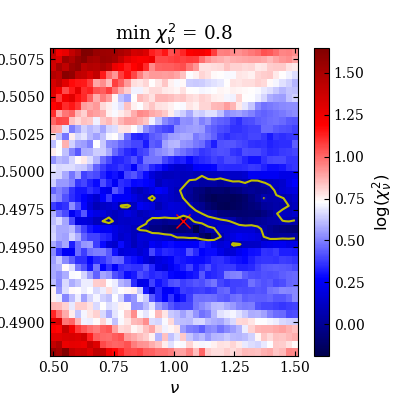

In [204]:
#Figuring out good initial values:
dc = DataCollapse(df_collapse, p_='p', L_='L', params={}, p_range=[0.48, 0.52],estimator='manual')
result = dc.parameter_sweep(
    p_c= np.linspace(0.488,0.508,40),
    nu=np.linspace(0.5, 1.5, 40),
    beta=0,
    n_jobs=-1,  # use all cores
    backend='threading',  # multiprocessing
)
plt.savefig("ParameterOptimization2DI.png")

In [189]:
res = dc.datacollapse(p_c=0.4985 ,nu =1.1579, beta=0.0,p_c_vary=True, nu_vary=True, beta_vary=False)
print(res.params)

Parameters([('p_c', <Parameter 'p_c', value=0.498550419309091 +/- 0.000134, bounds=[0:1]>), ('nu', <Parameter 'nu', value=1.13108166170418 +/- 0.0155, bounds=[0.5:2]>), ('beta', <Parameter 'beta', value=0.0 (fixed), bounds=[0:1]>)])


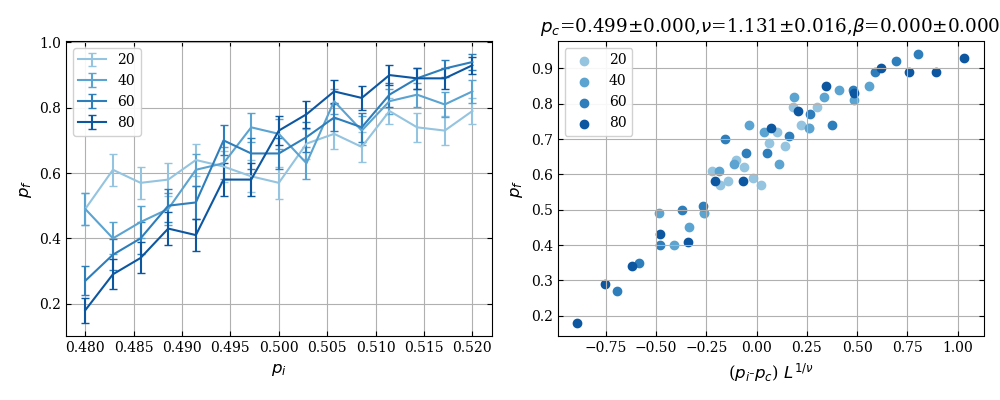

In [190]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

dc.plot_data_collapse(
    ax=ax1,
    raw=True,
    errorbar=True
)

dc.plot_data_collapse(
    ax=ax2
)

ax1.set_xlabel(r'$p_i$')
ax1.set_ylabel(r'$p_f$')
ax2.set_ylabel(r'$p_f$')

plt.tight_layout()
plt.savefig("DataCollapse(2DIsing).png")
plt.show()

#### Length vs Failure Probability for fixed P

In [30]:
#Fixed Temperature and Hamiltonian Parameters
J = 1
Tn = 0.0

#Search Parameters and Arrays
L_arr = [5,10, 15,20,30,40]
pf_arr = []
p_arr = [0.2, 0.3, 0.4]
FP_p= {p: [] for p in p_arr}
trials = 300 

#Search
for p_i in p_arr:
    for L_i in L_arr:
        fails_G = 0 
        total_G_steps = 0 
        for _ in tqdm(range(trials), desc=f"L={L_i}, p={p_i:.2f}"):
            mf_G, G_steps = FullEvolutionGT(L_i,Tn,p_i,J)
            total_G_steps += G_steps
            if mf_G != 1: #convergence to +1 zero temperature state
                fails_G += 1
        pf_G = fails_G/trials
        av_G_steps = total_G_steps/trials
        pf_arr.append(pf_G)
        FP_p[p_i].append(pf_G)

L=40, p=0.40: 100%|██████████| 300/300 [00:01<00:00, 159.40it/s]


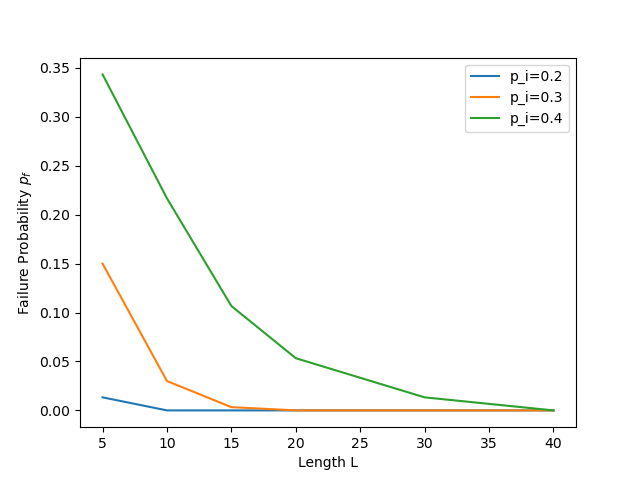

In [37]:
plt.figure()
for p_i in p_arr:
    plt.plot(L_arr, FP_p[p_i], label = f"p_i={p_i}")
plt.legend()
plt.xlabel("Length L")
plt.ylabel("Failure Probability $p_f$")
plt.savefig("2DGlLvpf(ph).png")
plt.show()